# Chargement du csv dans Hadoop

- hdfs dfs -mkdir -p /projet/bronze /projet/silver /projet/gold
- hdfs dfs -put ai_student_impact_dataset.csv /projet/bronze/
- hdfs dfs -ls /projet/bronze

# Spark


In [15]:
import os
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.19.10-hotspot"

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ia-etudiants").getOrCreate()

### Bronze - Chargement 

In [16]:
df_spark = spark.read.csv("hdfs://localhost:9000/projet/bronze/ai_student_impact_dataset.csv", header=True, inferSchema=True)
df_spark.printSchema()
df_spark.show(5)
print(df_spark.count())

root
 |-- Student_ID: integer (nullable = true)
 |-- Major_Category: string (nullable = true)
 |-- Year_of_Study: string (nullable = true)
 |-- Pre_Semester_GPA: double (nullable = true)
 |-- Weekly_GenAI_Hours: double (nullable = true)
 |-- Primary_Use_Case: string (nullable = true)
 |-- Prompt_Engineering_Skill: string (nullable = true)
 |-- Tool_Diversity: integer (nullable = true)
 |-- Paid_Subscription: boolean (nullable = true)
 |-- Traditional_Study_Hours: double (nullable = true)
 |-- Perceived_AI_Dependency: integer (nullable = true)
 |-- Institutional_Policy: string (nullable = true)
 |-- Anxiety_Level_During_Exams: integer (nullable = true)
 |-- Post_Semester_GPA: double (nullable = true)
 |-- Skill_Retention_Score: double (nullable = true)
 |-- Burnout_Risk_Level: string (nullable = true)

+----------+--------------+-------------+----------------+------------------+--------------------+------------------------+--------------+-----------------+-----------------------+-------

### Silver - cleaning dataset


In [17]:
# Exploration des données (pandas)
df = df_spark.toPandas()
print(f"Lignes: {len(df)} | Doublons (Student_ID): {df['Student_ID'].duplicated().sum()}")

Lignes: 50000 | Doublons (Student_ID): 0


In [18]:
# Valeurs manquantes par colonne
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [ ]:
# Statistiques descriptives (Spark, distribué)
numeric_cols = ["Pre_Semester_GPA", "Weekly_GenAI_Hours", "Tool_Diversity",
                 "Traditional_Study_Hours", "Perceived_AI_Dependency",
                 "Anxiety_Level_During_Exams", "Post_Semester_GPA", "Skill_Retention_Score"]

df_spark.select(numeric_cols).summary().show()

In [ ]:
# Écriture en Silver (HDFS, parquet)
# spark.createDataFrame(df).write.mode("overwrite").parquet("hdfs://localhost:9000/projet/silver/ai_student_impact_clean.parquet")

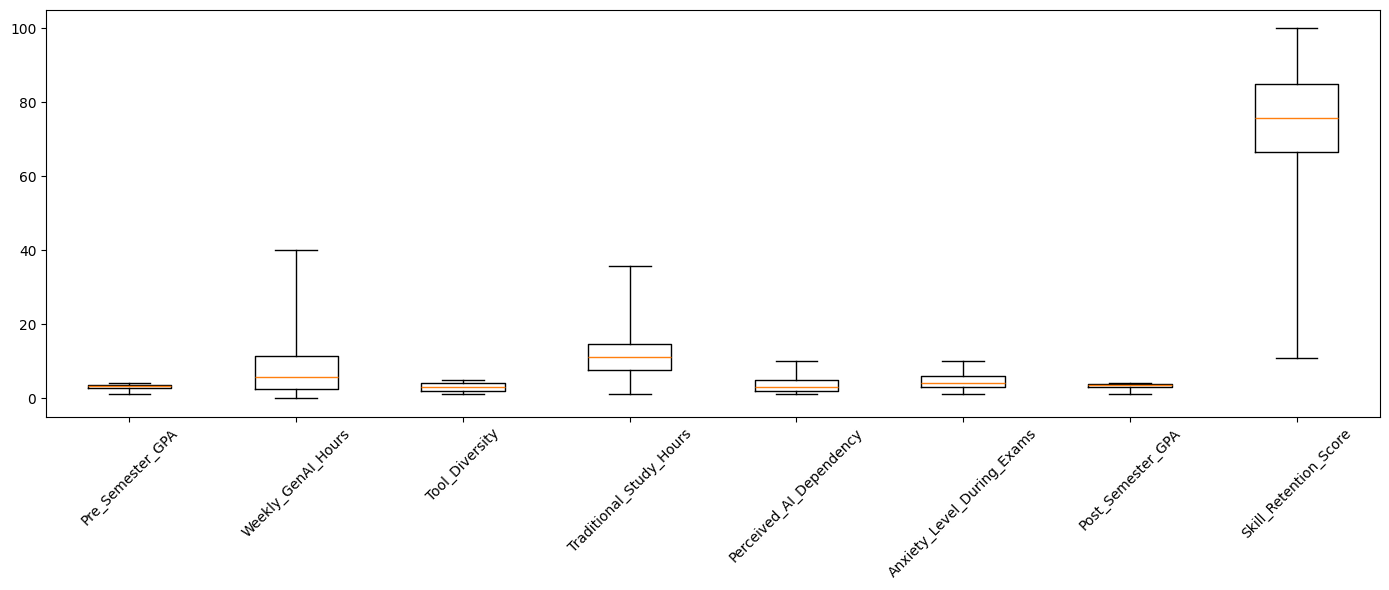

In [23]:
# Boîtes à moustache (Spark calcule les quantiles, matplotlib dessine juste le résumé)
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

quantiles = df_spark.approxQuantile(numeric_cols, [0.25, 0.5, 0.75], 0.01)
bounds = df_spark.agg(*[F.min(c).alias(f"{c}_min") for c in numeric_cols],
                       *[F.max(c).alias(f"{c}_max") for c in numeric_cols]).first()

stats = [
    {"label": c, "q1": q1, "med": med, "q3": q3,
     "whislo": bounds[f"{c}_min"], "whishi": bounds[f"{c}_max"]}
    for c, (q1, med, q3) in zip(numeric_cols, quantiles)
]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bxp(stats, showfliers=False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# Quantifier les valeurs aberrantes (méthode IQR, Spark)
for c, (q1, med, q3) in zip(numeric_cols, quantiles):
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df_spark.filter((F.col(c) < lo) | (F.col(c) > hi)).count()
    print(f"{c}: {outliers} valeurs aberrantes")

Pre_Semester_GPA: 339 valeurs aberrantes
Weekly_GenAI_Hours: 2725 valeurs aberrantes
Tool_Diversity: 0 valeurs aberrantes
Traditional_Study_Hours: 200 valeurs aberrantes
Perceived_AI_Dependency: 190 valeurs aberrantes
Anxiety_Level_During_Exams: 0 valeurs aberrantes
Post_Semester_GPA: 346 valeurs aberrantes
Skill_Retention_Score: 216 valeurs aberrantes


### Gold 